In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
# Load data
df = pd.read_csv('../data/loan.csv', low_memory=False)
# First look — run each line separately in Jupyter
print('Shape:', df.shape) # How many rows & columns?
print('Columns:', df.columns.tolist())
df.head(5) # First 5 rows
df.dtypes # Data types
df.describe()


Shape: (50000, 16)
Columns: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'loan_status', 'default']


,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,default
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,20399.439,17.539,1023.257,110355.042,19.978,2.008,2.506,10.042,0.995,24972.777,50.183,27.084,1.999,0.499,0.401
std,11178.001,7.221,562.120,52001.566,11.568,1.414,1.706,5.487,0.817,14407.335,28.809,12.975,1.415,0.500,0.490
min,1000.000,5.001,50.004,20001.964,0.001,0.000,0.000,1.000,0.000,1.557,0.002,5.000,0.000,0.000,0.000
25%,10782.000,11.299,534.702,65281.884,9.932,1.000,1.000,5.000,0.000,12571.221,25.154,16.000,1.000,0.000,0.000
50%,20363.000,17.504,1023.461,110472.722,19.994,2.000,3.000,10.000,1.000,25027.080,50.467,27.000,2.000,0.000,0.000
75%,29952.000,23.835,1504.792,155514.309,29.972,3.000,4.000,15.000,2.000,37387.037,75.009,38.000,3.000,1.000,1.000
max,39998.000,29.997,1999.875,199997.155,39.999,4.000,5.000,19.000,2.000,49999.347,100.000,49.000,4.000,1.000,1.000


In [2]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid            19910
Current               10040
Charged Off            7532
Late (16-30 days)      5058
Late (31-120 days)     4922
Default                2538
Name: count, dtype: int64


Default Rate: 40.1 %
default
0    29950
1    20050
Name: count, dtype: int64


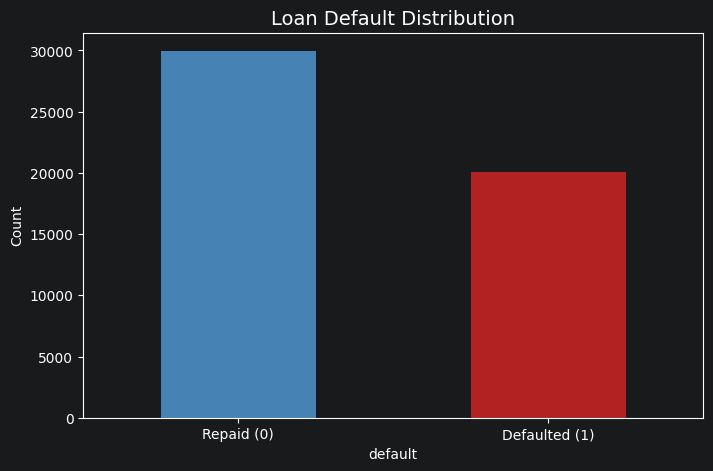

In [3]:
default_statuses = [
'Charged Off',
'Default',
'Does not meet the credit policy. Status:Charged Off',
'Late (31-120 days)',
'Late (16-30 days)'
]
df['default'] = df['loan_status'].isin(default_statuses).astype(int)
# Check class balance
print('Default Rate:', df['default'].mean() * 100, '%')
print(df['default'].value_counts())
# Visualize
plt.figure(figsize=(8,5))
df['default'].value_counts().plot(kind='bar', color=['steelblue','firebrick'])
plt.title('Loan Default Distribution', fontsize=14)
plt.xticks([0,1], ['Repaid (0)', 'Defaulted (1)'], rotation=0)
plt.ylabel('Count')
plt.savefig('../plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
selected_features = [
'loan_amnt', # Amount applied for
'int_rate', # Interest rate — higher = riskier customer
'installment', # Monthly payment amount
'annual_inc', # Annual income
'dti', # Debt-to-income ratio (CRITICAL feature)
'delinq_2yrs', # Times 30+ days late in last 2 years
'inq_last_6mths', # Credit inquiries in last 6 months
'open_acc', # Number of open credit accounts
'pub_rec', # Public derogatory records (bankruptcies)
'revol_bal', # Total credit revolving balance
'revol_util', # Revolving credit utilization rate
'total_acc', # Total credit accounts ever
'mort_acc', # Number of mortgage accounts
'pub_rec_bankruptcies', # Bankruptcies
'default' # Target variable
]
df_model = df[selected_features].copy()
print('Dataset shape after selection:', df_model.shape)
print(df_model.info())
# Save this for next notebook
df_model.to_csv('../data/loan_clean_eda.csv', index=False)
print('Saved → data/loan_clean_eda.csv')

Dataset shape after selection: (50000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             50000 non-null  int64  
 1   int_rate              50000 non-null  float64
 2   installment           50000 non-null  float64
 3   annual_inc            50000 non-null  float64
 4   dti                   50000 non-null  float64
 5   delinq_2yrs           50000 non-null  int64  
 6   inq_last_6mths        50000 non-null  int64  
 7   open_acc              50000 non-null  int64  
 8   pub_rec               50000 non-null  int64  
 9   revol_bal             50000 non-null  float64
 10  revol_util            50000 non-null  float64
 11  total_acc             50000 non-null  int64  
 12  mort_acc              50000 non-null  int64  
 13  pub_rec_bankruptcies  50000 non-null  int64  
 14  default               50000 non-null  

In [5]:
missing = df_model.isnull().sum()
missing_pct = (df_model.isnull().sum() / len(df_model) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10,6))

# 👉 FIX: store filtered values first
filtered_missing = missing_pct[missing_pct > 0]

if len(filtered_missing) > 0:
    filtered_missing.sort_values().plot(kind='barh', color='salmon')
    plt.title('Missing Values % by Feature', fontsize=14)
    plt.xlabel('Missing %')

    import os
    os.makedirs('../plots', exist_ok=True)  # ensure folder exists

    plt.savefig('../plots/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing values to plot ✅")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values to plot ✅


<Figure size 1000x600 with 0 Axes>

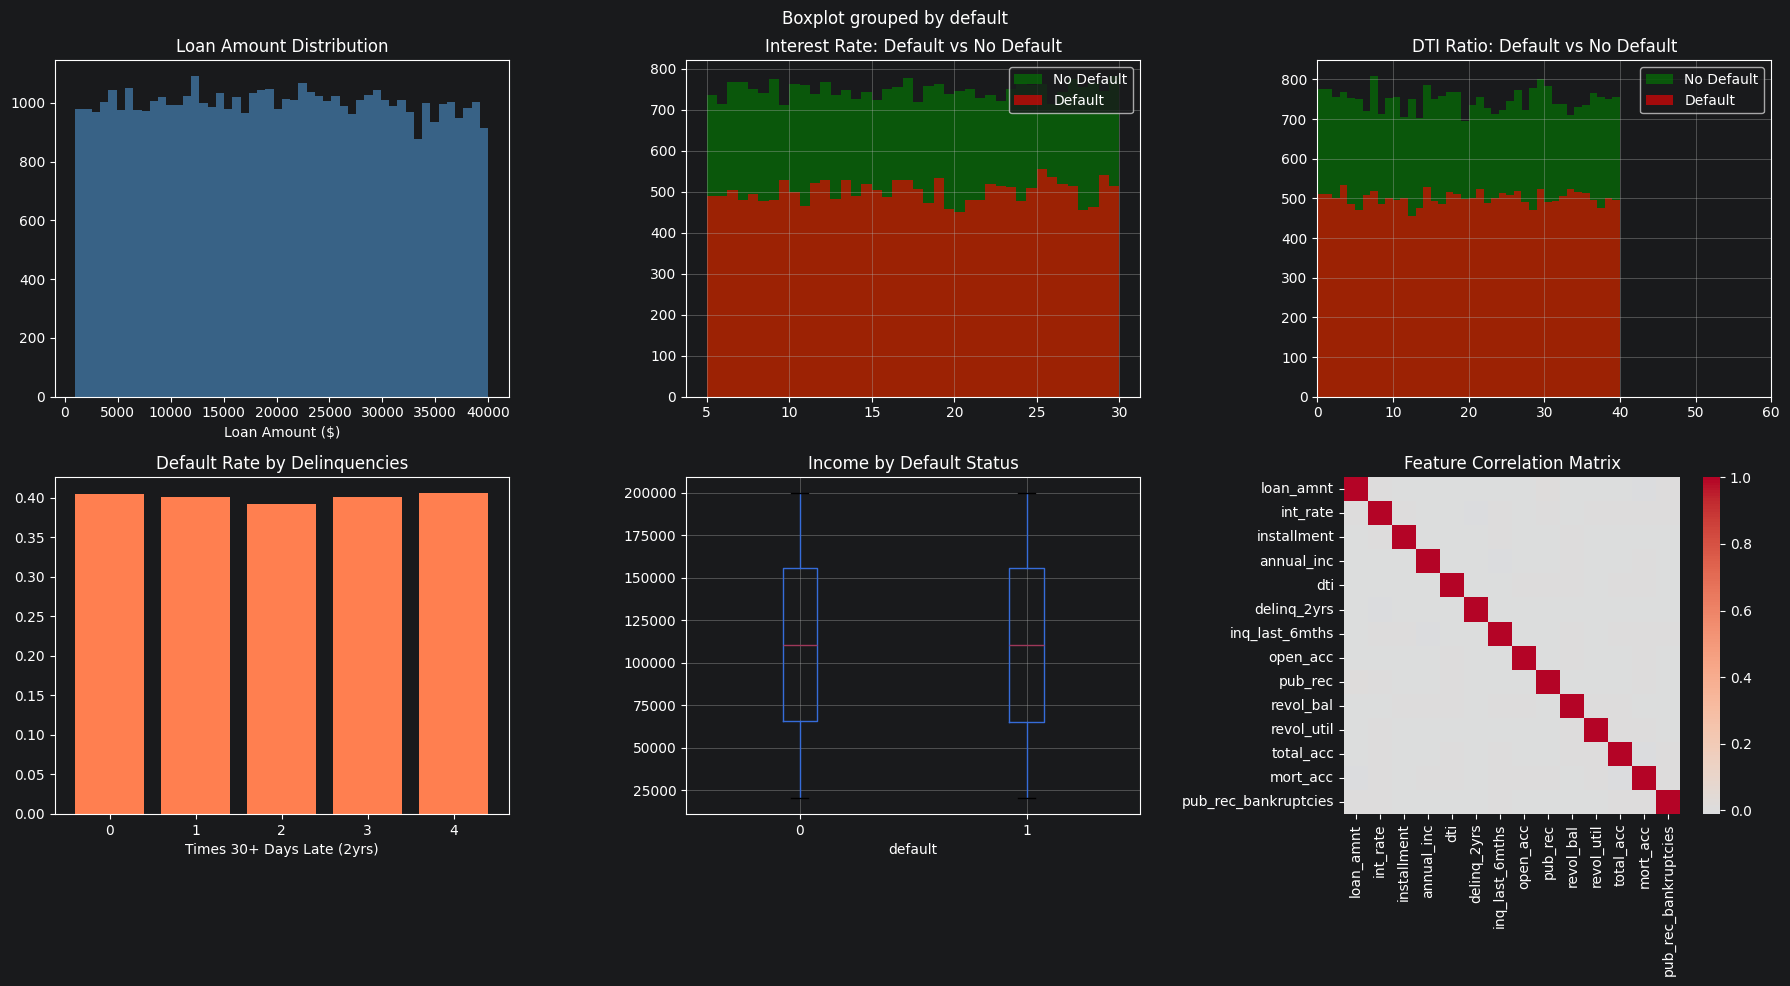

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Risk EDA — Key Distributions', fontsize=16, y=1.02)
# 1. Loan Amount Distribution
axes[0,0].hist(df_model['loan_amnt'], bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title('Loan Amount Distribution')
axes[0,0].set_xlabel('Loan Amount ($)')
# 2. Interest Rate by Default Status
df_model[df_model['default']==0]['int_rate'].hist(
ax=axes[0,1], bins=40, alpha=0.6, color='green', label='No Default')
df_model[df_model['default']==1]['int_rate'].hist(
ax=axes[0,1], bins=40, alpha=0.6, color='red', label='Default')
axes[0,1].set_title('Interest Rate: Default vs No Default')
axes[0,1].legend()
# 3. DTI Ratio by Default
df_model[df_model['default']==0]['dti'].hist(
ax=axes[0,2], bins=40, alpha=0.6, color='green', label='No Default')
df_model[df_model['default']==1]['dti'].hist(
ax=axes[0,2], bins=40, alpha=0.6, color='red', label='Default')
axes[0,2].set_title('DTI Ratio: Default vs No Default')
axes[0,2].set_xlim(0, 60)
axes[0,2].legend()
# 4. Default rate by delinquency
delinq_default = df_model.groupby('delinq_2yrs')['default'].mean()
axes[1,0].bar(delinq_default.index[:8], delinq_default.values[:8], color='coral')
axes[1,0].set_title('Default Rate by Delinquencies')
axes[1,0].set_xlabel('Times 30+ Days Late (2yrs)')
# 5. Annual Income vs Default (boxplot)
df_model[df_model['annual_inc'] < 200000].boxplot(
column='annual_inc', by='default', ax=axes[1,1])
axes[1,1].set_title('Income by Default Status')
# 6. Correlation heatmap
corr = df_model.drop('default', axis=1).corr()
sns.heatmap(corr, ax=axes[1,2], cmap='coolwarm', center=0,
annot=False, square=True)
axes[1,2].set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
